<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/exercise_08/Introduction_To_ML_Safety_Ex8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Practical: Attacking the CARLA Model

## Exercise 8.4: Generating Adversarial Examples

### Load your trained CARLA model and generate adversarial examples using the Fast

### Gradient Sign Method (FGSM):

### xadv = x + ε · sign(∇xL(y, f(x)))

In [2]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Model and test data path in drive

In [4]:
MODEL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
PEDESTRIAN_MODEL_PATH = os.path.join(MODEL_DIR, "pedestrian_detector.pth")
TRAFFIC_LIGHT_MODEL_PATH = os.path.join(MODEL_DIR, "traffic_light_detector.pth")
VEHICLE_MODEL_PATH = os.path.join(MODEL_DIR, "vehicle_detector.pth")
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"
TEST_CSV = os.path.join(TEST_DIR, "labels.csv")

print(os.path.exists(PEDESTRIAN_MODEL_PATH))
print(os.path.exists(TRAFFIC_LIGHT_MODEL_PATH))
print(os.path.exists(VEHICLE_MODEL_PATH))
print(os.path.exists(TEST_CSV))


True
True
True
True


Load Labels

In [5]:
test_df = pd.read_csv(TEST_CSV)
test_df.columns = [c.strip().lower() for c in test_df.columns]

print(test_df.head())
print(test_df.columns)
print("Number of test images:", len(test_df))

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  
Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')
Number of test images: 3600


In [6]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

In [7]:
fgsm_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [8]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

In [9]:
def normalize_batch(images):
    return torch.stack([normalize(img) for img in images])

create dataset class for loading the data

In [10]:
class CarlaBinaryDataset(Dataset):
    def __init__(self, dataframe, root_dir, label_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = build_image_path(self.root_dir, row["frame"])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(float(row[self.label_column]), dtype=torch.float32)

        return image, label

create model function

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def create_model():
    model = models.resnet18(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    model = model.to(device)
    return model

Using device: cuda


load models

In [12]:
pedestrian_model = create_model()
pedestrian_model.load_state_dict(torch.load(PEDESTRIAN_MODEL_PATH, map_location=device))
pedestrian_model.eval()

traffic_light_model = create_model()
traffic_light_model.load_state_dict(torch.load(TRAFFIC_LIGHT_MODEL_PATH, map_location=device))
traffic_light_model.eval()

vehicle_model = create_model()
vehicle_model.load_state_dict(torch.load(VEHICLE_MODEL_PATH, map_location=device))
vehicle_model.eval()

print("All models loaded successfully.")

All models loaded successfully.


## 1. Implement FGSM for each of your three binary classifiers.

fgsm function to create perturbation in the images (disturbance)

In [24]:
def fgsm_attack_batch(model, images, labels, epsilon):
    """
    Generates FGSM adversarial examples for a batch.

    images: clean images in [0,1], shape [B,3,224,224]
    labels: true binary labels, shape [B]
    epsilon: perturbation strength
    """

    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.view(-1, 1).to(device)

    images.requires_grad = True

    # Normalize images before feeding them into the model
    images_normalized = normalize_batch(images)

    # Forward pass
    logits = model(images_normalized)

    # Binary classification loss
    loss_fn = nn.BCEWithLogitsLoss()
    loss = loss_fn(logits, labels)

    # Backward pass: compute gradient w.r.t. input image
    model.zero_grad()
    loss.backward()

    # FGSM formula
    adv_images = images + epsilon * images.grad.sign()

    # Keep pixels in valid range [0,1]
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

Optionally can calculate probabilities after perburtation

In [19]:
# def predict_single_from_tensor(model, image_tensor):
#     model.eval()

#     image_tensor = image_tensor.unsqueeze(0).to(device)

#     with torch.no_grad():
#         image_normalized = normalize_batch(image_tensor)
#         logits = model(image_normalized)
#         prob = torch.sigmoid(logits).item()
#         pred = 1 if prob >= 0.5 else 0

#     return pred, prob

In [20]:
# def tensor_to_image(tensor):
#     image = tensor.detach().cpu().permute(1, 2, 0).numpy()
#     image = np.clip(image, 0, 1)
#     return image

## 2. Generate adversarial examples for ε ∈ {0.01, 0.05, 0.1}.

In [25]:
def show_clean_vs_adversarial_dynamic(
    model,
    model_name,
    label_column,
    epsilon,
    dataframe=test_df,
    root_dir=TEST_DIR,
    transform=fgsm_transform,
    batch_size=32,
    image_index=0
):
    # Create dataset dynamically
    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        root_dir=root_dir,
        label_column=label_column,
        transform=transform
    )

    # Create dataloader dynamically
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    # Take one batch
    images, labels = next(iter(loader))

    # Generate adversarial images
    adv_images = fgsm_attack_batch(
        model=model,
        images=images,
        labels=labels,
        epsilon=epsilon
    )

    # Select one image from the batch
    clean_image = images[image_index]
    adv_image = adv_images[image_index]

    true_label = int(labels[image_index].item())

    # Predictions only for display titles
    # clean_pred, clean_prob = predict_single_from_tensor(model, clean_image)
    # adv_pred, adv_prob = predict_single_from_tensor(model, adv_image)

    # Convert tensors to images
    clean_img_np = tensor_to_image(clean_image)
    adv_img_np = tensor_to_image(adv_image)

    # Display side-by-side
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(clean_img_np)
    plt.axis("off")
    plt.title(
        f"Clean"
        # \nTrue: {true_label}, Pred: {clean_pred}, Prob: {clean_prob:.3f}"
    )

    plt.subplot(1, 2, 2)
    plt.imshow(adv_img_np)
    plt.axis("off")
    plt.title(
        f"Adversarial ε={epsilon}"
        # \nPred: {adv_pred}, Prob: {adv_prob:.3f}

    )

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.show()

## 3. Display a clean image and its adversarial counterpart side-by-side. At what ε do the perturbations become visible to a human?

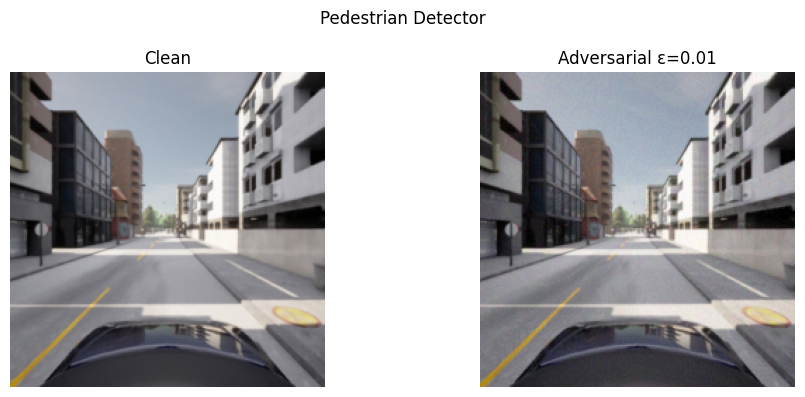

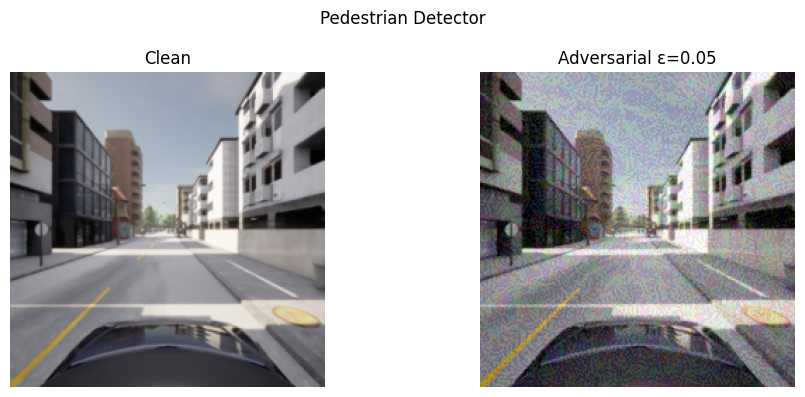

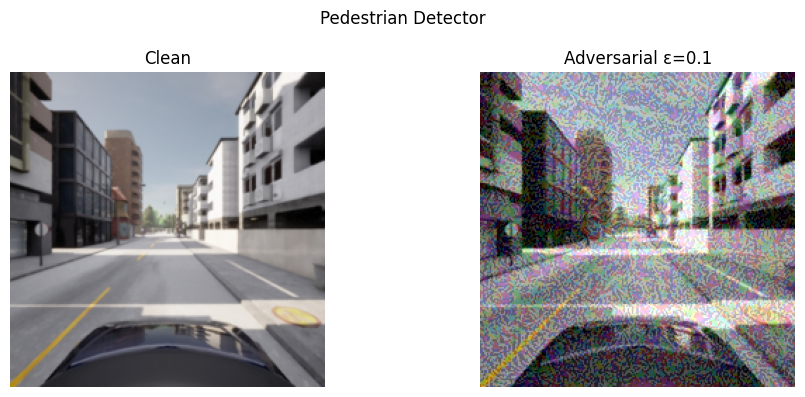

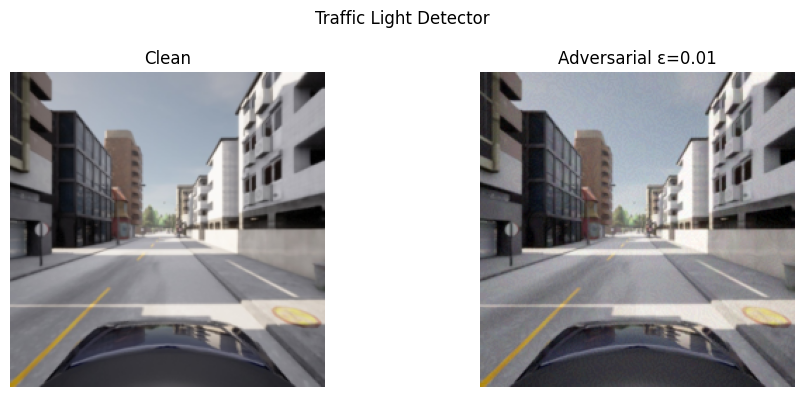

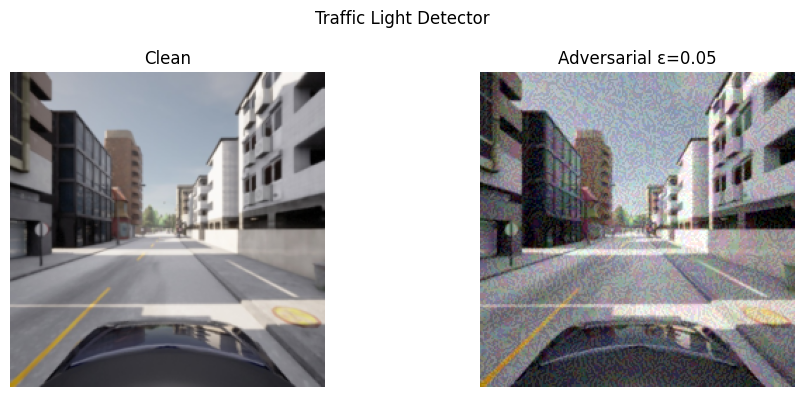

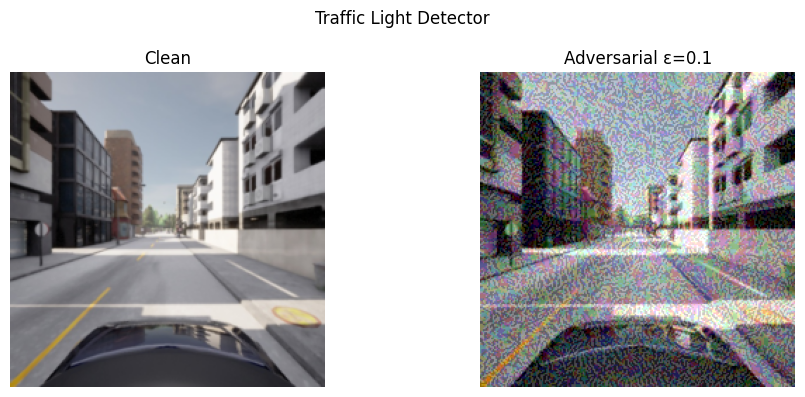

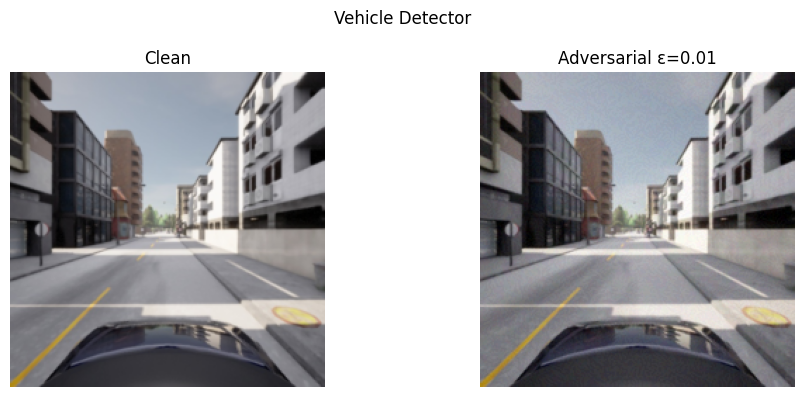

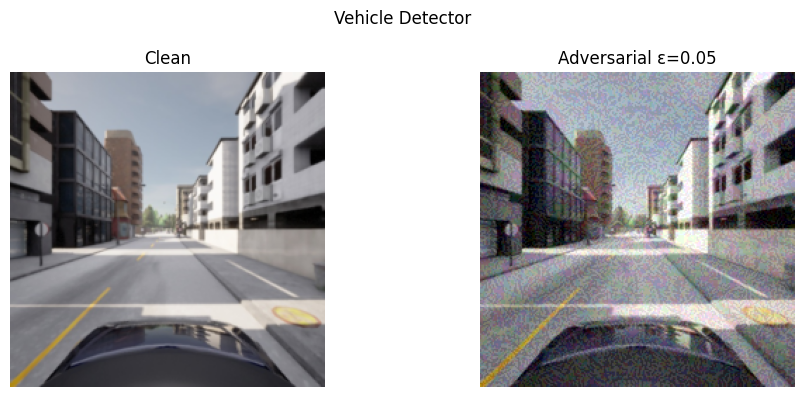

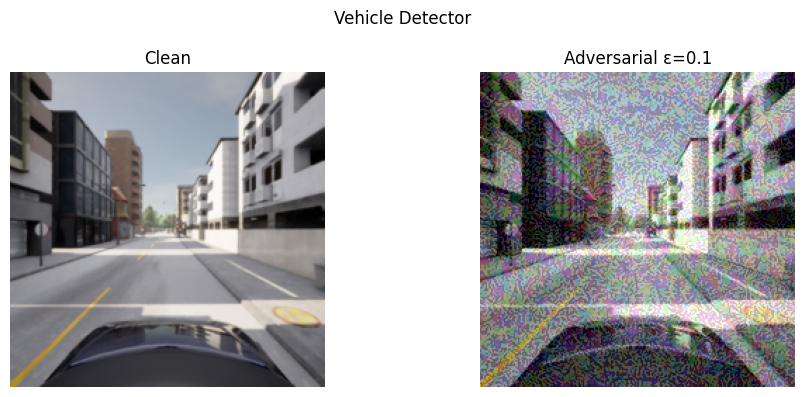

In [26]:
epsilons = [0.01, 0.05, 0.1]

models_info = [
    {
        "model": pedestrian_model,
        "model_name": "Pedestrian Detector",
        "label_column": "has_pedestrian"
    },
    {
        "model": traffic_light_model,
        "model_name": "Traffic Light Detector",
        "label_column": "has_traffic_light"
    },
    {
        "model": vehicle_model,
        "model_name": "Vehicle Detector",
        "label_column": "has_vehicle"
    }
]

for info in models_info:
    for eps in epsilons:
        show_clean_vs_adversarial_dynamic(
            model=info["model"],
            model_name=info["model_name"],
            label_column=info["label_column"],
            epsilon=eps,
            batch_size=8,
            image_index=0
        )

-->

The perturbation for ϵ=0.01 is almost invisible.

For ϵ=0.05, small noise started to become visible when comparing the clean and adversarial images side-by-side.

For ϵ=0.1, the perturbation is clearly visible as image noise or color distortion.

--> Therefore, the perturbation starts becoming visible around ϵ=0.05, and is clearly visible at ϵ=0.1.

## Exercise 8.5 Evaluate each of your three models on the adversarial test set for each ε. (You may also use a subset of 100 randomly sampled images for evaluation.) Report the per-model recall drop compared to clean inputs.

In [27]:
from sklearn.metrics import recall_score

In [28]:
def predict_batch(model, images):
    model.eval()

    images = images.to(device)

    with torch.no_grad():
        images_normalized = normalize_batch(images)
        logits = model(images_normalized)
        probs = torch.sigmoid(logits).view(-1)
        preds = (probs >= 0.5).int()

    return preds.cpu().numpy(), probs.cpu().numpy()

In [29]:
def evaluate_recall_drop_fgsm(
    model,
    model_name,
    label_column,
    epsilon,
    dataframe,
    root_dir=TEST_DIR,
    transform=fgsm_transform,
    batch_size=32
):
    dataset = CarlaBinaryDataset(
        dataframe=dataframe,
        root_dir=root_dir,
        label_column=label_column,
        transform=transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_labels = []
    clean_preds_all = []
    adv_preds_all = []

    model.eval()

    for images, labels in loader:
        # Generate adversarial images using FGSM
        adv_images = fgsm_attack_batch(
            model=model,
            images=images,
            labels=labels,
            epsilon=epsilon
        )

        # Clean predictions
        clean_preds, _ = predict_batch(model, images)

        # Adversarial predictions
        adv_preds, _ = predict_batch(model, adv_images)

        all_labels.extend(labels.numpy().astype(int))
        clean_preds_all.extend(clean_preds)
        adv_preds_all.extend(adv_preds)

    clean_recall = recall_score(
        all_labels,
        clean_preds_all,
        zero_division=0
    )

    adversarial_recall = recall_score(
        all_labels,
        adv_preds_all,
        zero_division=0
    )

    recall_drop = clean_recall - adversarial_recall

    return {
        "Model": model_name,
        "Epsilon": epsilon,
        "Clean Recall": clean_recall,
        "Adversarial Recall": adversarial_recall,
        "Recall Drop": recall_drop
    }

In [30]:
fgsm_recall_results = []

for info in models_info:
    for eps in epsilons:
        print(f"Evaluating {info['model_name']} with epsilon={eps}")

        result = evaluate_recall_drop_fgsm(
            model=info["model"],
            model_name=info["model_name"],
            label_column=info["label_column"],
            epsilon=eps,
            dataframe=test_df,
            batch_size=32
        )

        fgsm_recall_results.append(result)

print("Done.")

Evaluating Pedestrian Detector with epsilon=0.01
Evaluating Pedestrian Detector with epsilon=0.05
Evaluating Pedestrian Detector with epsilon=0.1
Evaluating Traffic Light Detector with epsilon=0.01
Evaluating Traffic Light Detector with epsilon=0.05
Evaluating Traffic Light Detector with epsilon=0.1
Evaluating Vehicle Detector with epsilon=0.01
Evaluating Vehicle Detector with epsilon=0.05
Evaluating Vehicle Detector with epsilon=0.1
Done.


In [31]:
fgsm_recall_df = pd.DataFrame(fgsm_recall_results)
fgsm_recall_df.round(4)

,Model,Epsilon,Clean Recall,Adversarial Recall,Recall Drop
0,Pedestrian Detector,0.01,0.3385,0.0000,0.3385
1,Pedestrian Detector,0.05,0.3385,0.0142,0.3244
2,Pedestrian Detector,0.10,0.3385,0.1686,0.1700
3,Traffic Light Detector,0.01,0.9717,0.0008,0.9710
4,Traffic Light Detector,0.05,0.9717,0.0008,0.9710
5,Traffic Light Detector,0.10,0.9717,0.0008,0.9710
6,Vehicle Detector,0.01,0.8893,0.2141,0.6752
7,Vehicle Detector,0.05,0.8893,0.3178,0.5715
8,Vehicle Detector,0.10,0.8893,0.1948,0.6944


The recall drop is not perfectly monotonic for every model. For example, the pedestrian detector has lower recall drop at ϵ=0.10 than at ϵ=0.01. This can happen because neural networks are non-linear, clipping keeps pixel values inside [0,1], and larger perturbations do not always move all samples in a consistently worse direction. However, the overall result is still clear: FGSM strongly degrades recall.